In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Fill missing values
data["TotalCharges"] = data["TotalCharges"].fillna(
    data["TotalCharges"].median()
)

# Convert target variable
data["Churn"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Remove customer ID
data = data.drop(columns=["customerID"])

# Separate features and target
y = data["Churn"]
X = data.drop(columns=["Churn"])

# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object"]).columns,
    drop_first=True,
    dtype=int
)

print("Dataset prepared successfully!")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset prepared successfully!
Features: (7043, 30)
Target: (7043,)


C:\Users\aatik\AppData\Local\Temp\ipykernel_2684\3642516232.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns=X.select_dtypes(include=["object"]).columns,


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Train-test split completed!
Training data: (5634, 30)
Testing data: (1409, 30)


In [18]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8069552874378992


In [19]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation setup completed!")

5-Fold Cross-Validation setup completed!


In [20]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

print("Models defined successfully!")

Models defined successfully!


In [21]:
cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="accuracy"
    )
    
    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std(),
        "Minimum Accuracy": scores.min(),
        "Maximum Accuracy": scores.max()
    })
    
    print(f"\n{name}")
    print("Fold Scores:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Standard Deviation:", scores.std())


Logistic Regression
Fold Scores: [0.81973031 0.80979418 0.80198722 0.79332386 0.81036932]
Mean Accuracy: 0.8070409784502226
Standard Deviation: 0.008869911402478914

KNN
Fold Scores: [0.77146913 0.75727466 0.73314407 0.76917614 0.76065341]
Mean Accuracy: 0.758343481837538
Standard Deviation: 0.013646371450525026

Decision Tree
Fold Scores: [0.80624556 0.79701916 0.77430802 0.78196023 0.78835227]
Mean Accuracy: 0.7895770493257629
Standard Deviation: 0.011188241634515027

Random Forest
Fold Scores: [0.79701916 0.80624556 0.78637331 0.78053977 0.79119318]
Mean Accuracy: 0.7922741991418801
Standard Deviation: 0.008847593145374998


In [22]:
cv_comparison = pd.DataFrame(cv_results)

print("\nCross-Validation Comparison:")
print(cv_comparison)


Cross-Validation Comparison:
                 Model  Mean CV Accuracy  Std CV Accuracy  Minimum Accuracy  \
0  Logistic Regression          0.807041         0.008870          0.793324   
1                  KNN          0.758343         0.013646          0.733144   
2        Decision Tree          0.789577         0.011188          0.774308   
3        Random Forest          0.792274         0.008848          0.780540   

   Maximum Accuracy  
0          0.819730  
1          0.771469  
2          0.806246  
3          0.806246  


In [23]:
logistic_cv_scores = cross_val_score(
    models["Logistic Regression"],
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

logistic_cv_mean = logistic_cv_scores.mean()
logistic_cv_std = logistic_cv_scores.std()

comparison = pd.DataFrame({
    "Evaluation Method": [
        "Train-Test Split",
        "5-Fold Cross-Validation"
    ],
    "Accuracy": [
        logistic_accuracy,
        logistic_cv_mean
    ],
    "Standard Deviation": [
        np.nan,
        logistic_cv_std
    ]
})

print(comparison)

         Evaluation Method  Accuracy  Standard Deviation
0         Train-Test Split  0.806955                 NaN
1  5-Fold Cross-Validation  0.807041             0.00887


In [24]:
print("MODEL STABILITY ANALYSIS")
print("-" * 40)

for result in cv_results:
    print(
        f"{result['Model']}: "
        f"Mean = {result['Mean CV Accuracy']:.4f}, "
        f"Std = {result['Std CV Accuracy']:.4f}"
    )

print("\nLower standard deviation indicates more consistent")
print("performance across different folds.")

MODEL STABILITY ANALYSIS
----------------------------------------
Logistic Regression: Mean = 0.8070, Std = 0.0089
KNN: Mean = 0.7583, Std = 0.0136
Decision Tree: Mean = 0.7896, Std = 0.0112
Random Forest: Mean = 0.7923, Std = 0.0088

Lower standard deviation indicates more consistent
performance across different folds.


In [25]:
cv_comparison.to_csv(
    "cross_validation_performance_comparison.csv",
    index=False
)

comparison.to_csv(
    "train_test_vs_cross_validation.csv",
    index=False
)

print("Performance reports saved successfully!")

Performance reports saved successfully!


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


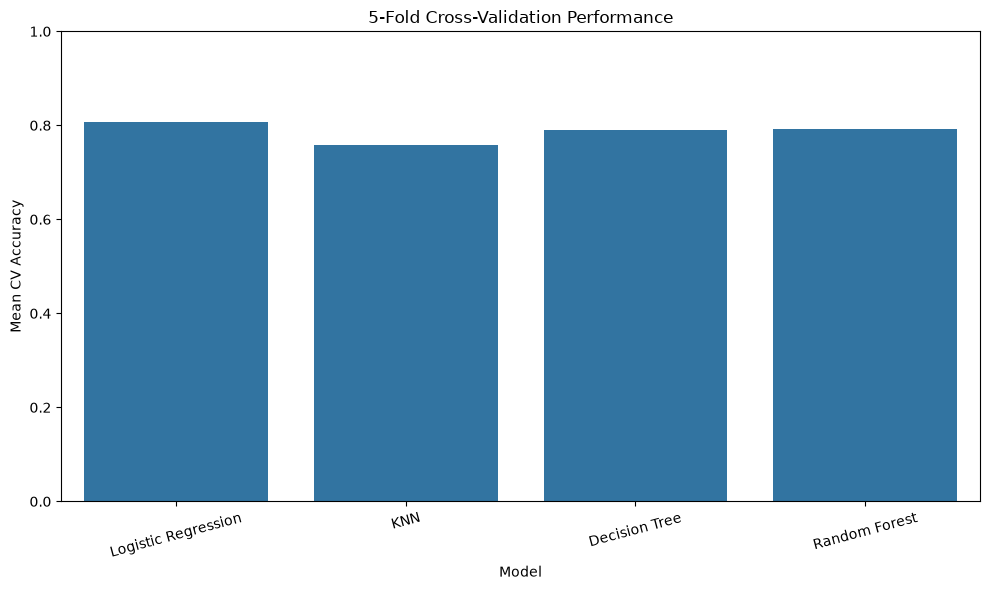

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_comparison,
    x="Model",
    y="Mean CV Accuracy"
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

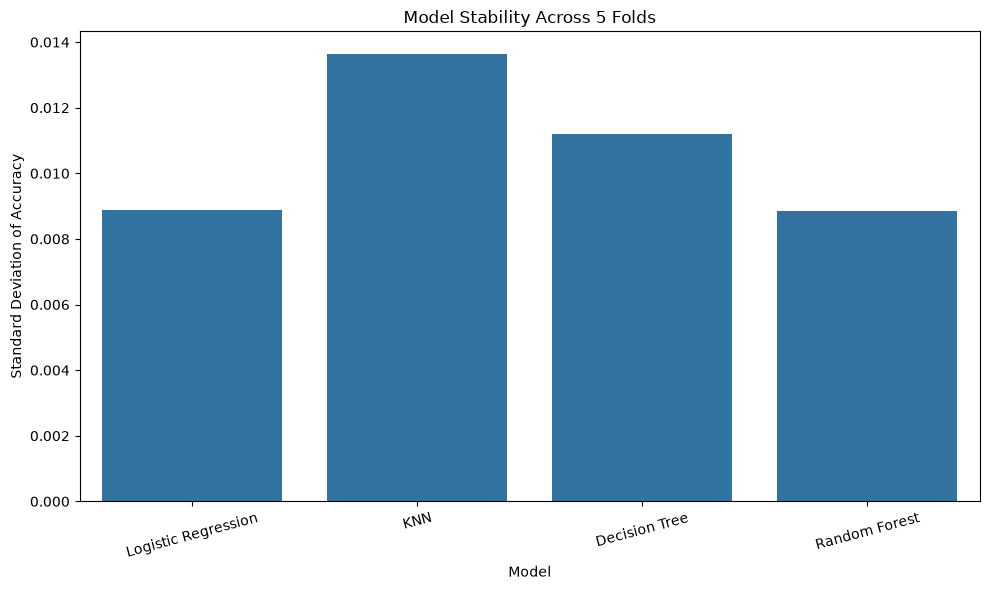

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_comparison,
    x="Model",
    y="Std CV Accuracy"
)

plt.title("Model Stability Across 5 Folds")
plt.xlabel("Model")
plt.ylabel("Standard Deviation of Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

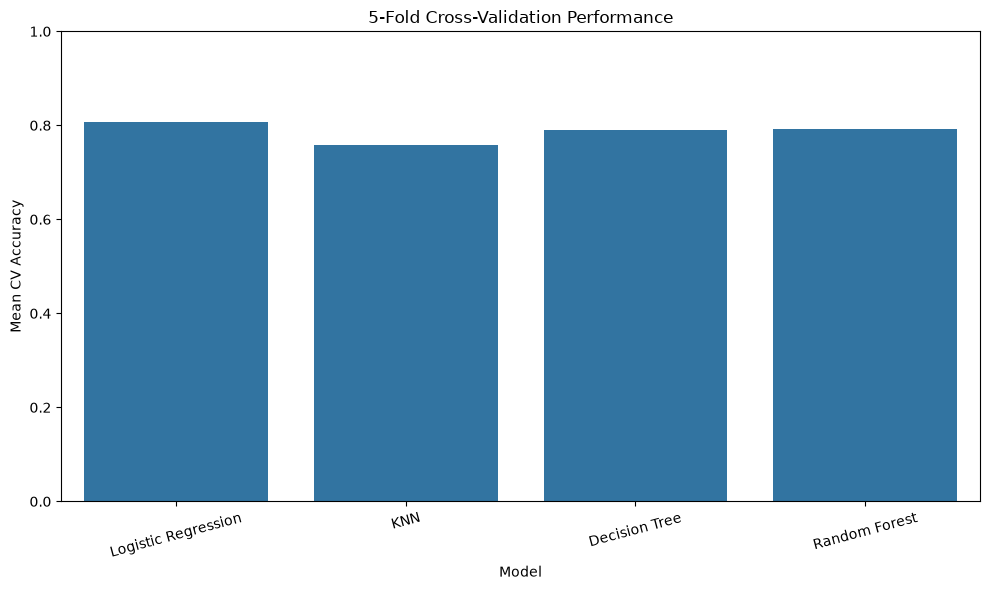

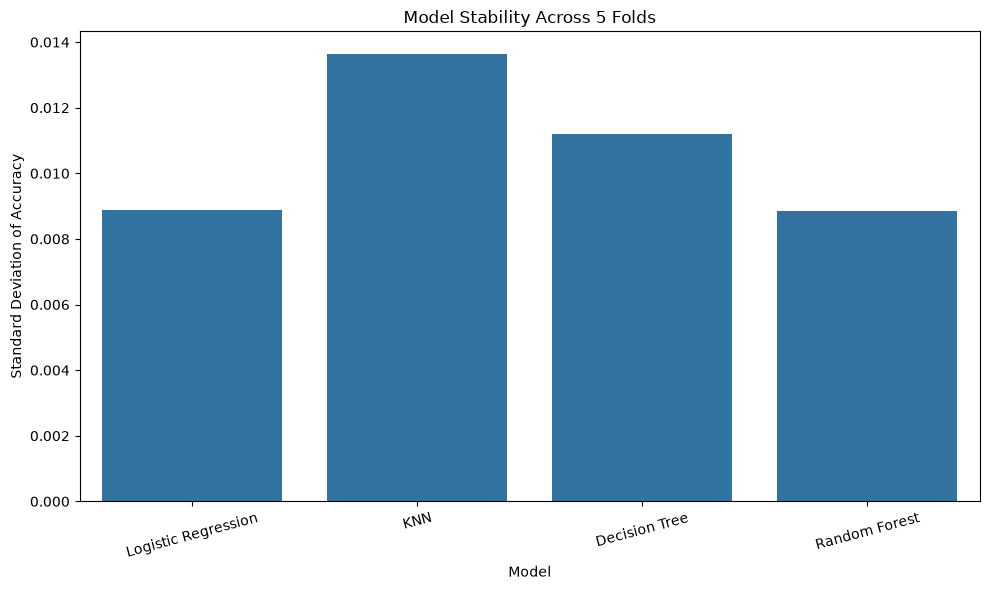

Both visualizations saved successfully!


In [31]:
# Save cross-validation performance plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_comparison,
    x="Model",
    y="Mean CV Accuracy"
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("cross_validation_performance.png", dpi=300)
plt.show()

# Save model stability plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_comparison,
    x="Model",
    y="Std CV Accuracy"
)

plt.title("Model Stability Across 5 Folds")
plt.xlabel("Model")
plt.ylabel("Standard Deviation of Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_stability.png", dpi=300)
plt.show()

print("Both visualizations saved successfully!")

In [32]:
print("CROSS-VALIDATION RELIABILITY ANALYSIS")
print("-" * 45)

for result in cv_results:
    mean_score = result["Mean CV Accuracy"]
    std_score = result["Std CV Accuracy"]

    print(f"\n{result['Model']}")
    print(f"Mean CV Accuracy: {mean_score:.4f}")
    print(f"Standard Deviation: {std_score:.4f}")
    print(f"Accuracy Range: {result['Minimum Accuracy']:.4f} - {result['Maximum Accuracy']:.4f}")

print("\nKey Observations:")
print("1. Cross-validation evaluates the model across multiple data splits.")
print("2. Mean CV accuracy represents average model performance.")
print("3. Standard deviation indicates how much performance varies between folds.")
print("4. A smaller standard deviation indicates more consistent performance.")
print("5. Cross-validation provides a more reliable evaluation than relying on a single train-test split.")

CROSS-VALIDATION RELIABILITY ANALYSIS
---------------------------------------------

Logistic Regression
Mean CV Accuracy: 0.8070
Standard Deviation: 0.0089
Accuracy Range: 0.7933 - 0.8197

KNN
Mean CV Accuracy: 0.7583
Standard Deviation: 0.0136
Accuracy Range: 0.7331 - 0.7715

Decision Tree
Mean CV Accuracy: 0.7896
Standard Deviation: 0.0112
Accuracy Range: 0.7743 - 0.8062

Random Forest
Mean CV Accuracy: 0.7923
Standard Deviation: 0.0088
Accuracy Range: 0.7805 - 0.8062

Key Observations:
1. Cross-validation evaluates the model across multiple data splits.
2. Mean CV accuracy represents average model performance.
3. Standard deviation indicates how much performance varies between folds.
4. A smaller standard deviation indicates more consistent performance.
5. Cross-validation provides a more reliable evaluation than relying on a single train-test split.
